> Benjamin Nikholas

> Data Science / JCSDOL-014

> Modul 2 - Tugas 30

> 27 Juni 2024
---
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = 10, 6
import seaborn as sns
from itertools import chain

In [68]:
df = pd.read_csv('data.csv')
df['purchase_time'] = pd.to_datetime(df['purchase_time'])
df

,receipt_id,receipts_item_id,purchase_time,category,sub_category,format,unit_price,discount,quantity
0,9622257,32369294,2018-07-22 21:19:00,Rice,Rice,supermarket,128000.0,0,1
1,9446359,31885876,2018-07-15 16:17:00,Rice,Rice,minimarket,102750.0,0,1
2,9470290,31930241,2018-07-15 12:12:00,Rice,Rice,supermarket,64000.0,0,3
3,9643416,32418582,2018-07-24 08:27:00,Rice,Rice,minimarket,65000.0,0,1
4,9692093,32561236,2018-07-26 11:28:00,Rice,Rice,supermarket,124500.0,0,1
...,...,...,...,...,...,...,...,...,...
71995,5909305,17998610,2017-12-27 09:20:00,Sugar/Flavored Syrup,Sugar,minimarket,25000.0,0,1
71996,5736299,17432379,2017-12-13 19:52:00,Sugar/Flavored Syrup,Sugar,minimarket,12500.0,0,1
71997,5901144,18263665,2017-12-27 08:03:00,Sugar/Flavored Syrup,Sugar,minimarket,12500.0,0,1
71998,5660630,17222218,2017-12-07 12:29:00,Sugar/Flavored Syrup,Sugar,hypermarket,12500.0,0,3


2. Hitung Jumlah transaksi di Hypermarket pada tahun 2018 untuk masing - masing sub category

In [69]:
df_2018_hypermarket = df[(df.purchase_time.dt.year == 2018) & (df.format == 'supermarket')]

pivot_df_2018 = pd.pivot_table(data = df_2018_hypermarket,
                               values = 'unit_price',
                               index = 'sub_category',
                               aggfunc = 'count').rename({'unit_price':'transaction_hypermarket'}, axis = 1)
pivot_df_2018

,transaction_hypermarket
sub_category,
Detergent,6870
Rice,2902
Sugar,5118


3. Di bulan apa dan tahun berapa penjualan (Total payment) di supermarket 
mencapai jumlah tertinggi

In [117]:
df['total_payment'] = (df.unit_price - df.discount) * df.quantity
df['year_month'] = df['purchase_time'].dt.to_period('M')

total_payment_my = pd.pivot_table(data = df[df.format == 'supermarket'],
                                  values = 'total_payment',
                                  index = ['year_month'],
                                  aggfunc = 'sum')
display(total_payment_my)

max_m = total_payment_my.idxmax().dt.month.values[0]
max_y = total_payment_my.idxmax().dt.year.values[0]

print(f'\nPenjualan (total_payment_my) mencapai jumlah tertinggi {total_payment_my.max().values[0]} di bulan {max_m} dan tahun {max_y}')

,total_payment
year_month,
2017-10,6.106911e+07
2017-11,6.046641e+07
2017-12,6.060280e+07
2018-01,5.779255e+07
2018-02,5.999970e+07
2018-03,6.217920e+07
2018-04,5.833869e+07
2018-05,6.500843e+07
2018-06,5.603278e+07



Penjualan (total_payment_my) mencapai jumlah tertinggi 65008429.0 di bulan 5 dan tahun 2018


4. Produk dari Sub kategori mana yg menyumbang transaksi/penjualan 
tertinggi di No 2 (Bulan dan Tahun)

In [144]:
total_payment_sub = pd.pivot_table(data = df[df.format == 'supermarket'],
                                   values = 'total_payment',
                                   index = ['sub_category'],
                                   aggfunc = 'sum').sort_values(by = 'total_payment')
display(total_payment_sub)
second_sales_sub = total_payment_sub.iloc[1:-1]

print(f'Produk sub kategori penyumbang penjualan tertinggi kedua adalah {second_sales_sub.index.values[0]}')

,total_payment
sub_category,
Sugar,1.504225e+08
Detergent,1.809693e+08
Rice,3.574660e+08


Produk sub kategori penyumbang penjualan tertinggi kedua adalah Detergent


5. Produk dari sub kategori apa dan hari apa yg memiliki quantity 
tertinggi di tahun 2017 dan di hypermarket

In [172]:
df['day_name'] = df.purchase_time.dt.day_name()
df_2017_hypermarket = df[(df.purchase_time.dt.year == 2017) & (df.format == 'supermarket')]
df_2017_hypermarket

day_sub_category = pd.pivot_table(data = df,
                                  values = 'quantity',
                                  index = ['sub_category', 'day_name'],
                                  aggfunc = 'sum')
display(day_sub_category)

best_sub, best_sales_day = day_sub_category.idxmax().values[0]
print(f'Produk sub kategori dengan quantity tertinggi adalah {best_sub} dan pada hari {best_sales_day}')

quantity
sub_category day_name           
Detergent    Friday         8216
             Monday         5845
             Saturday       8626
             Sunday         8751
             Thursday       5923
             Tuesday        6193
             Wednesday      6106
Rice         Friday         2273
             Monday         2037
             Saturday       2581
             Sunday         3009
             Thursday       2068
             Tuesday        2078
             Wednesday      1949
Sugar        Friday         5940
             Monday         5427
             Saturday       6506
             Sunday         6504
             Thursday       5627
             Tuesday        5527
             Wednesday      5580

Produk sub kategori dengan quantity tertinggi adalah Detergent dan pada hari Sunday


6. Perusahaan ingin melakukan efisiensi kasir di minimarket, berdasarkan 
jumlah transaksi dan kelompok Shift Kasir

In [194]:
determine_shift = []

for i in df.purchase_time.dt.hour:
    if 0 <= i < 6:
        determine_shift.append('00:00 - 05:00')
    elif 6 <= i < 12:
        determine_shift.append('06:00 - 11:00')
    elif 12 <= i < 18:
        determine_shift.append('12:00 - 17:00')
    else:
        determine_shift.append('18:00 - 23:00')

df['shift'] = determine_shift

display(df.sample(5))

,receipt_id,receipts_item_id,purchase_time,category,sub_category,format,unit_price,discount,quantity,total_payment,year_month,day_name,shift
53971,11225101,37440218,2018-09-24 16:08:00,Sugar/Flavored Syrup,Sugar,supermarket,12500.0,0,10,125000.0,2018-09,Monday,12:00 - 17:00
70202,5657276,17178457,2017-12-04 20:46:00,Sugar/Flavored Syrup,Sugar,minimarket,12500.0,0,1,12500.0,2017-12,Monday,18:00 - 23:00
15778,10217449,34227222,2018-08-15 00:00:00,Fabric Care,Detergent,minimarket,20000.0,0,1,20000.0,2018-08,Wednesday,00:00 - 05:00
6709,7566773,22761114,2018-04-06 18:18:00,Rice,Rice,minimarket,62500.0,0,3,187500.0,2018-04,Friday,18:00 - 23:00
54002,6270366,19032607,2018-01-21 19:43:00,Sugar/Flavored Syrup,Sugar,minimarket,12500.0,0,3,37500.0,2018-01,Sunday,18:00 - 23:00


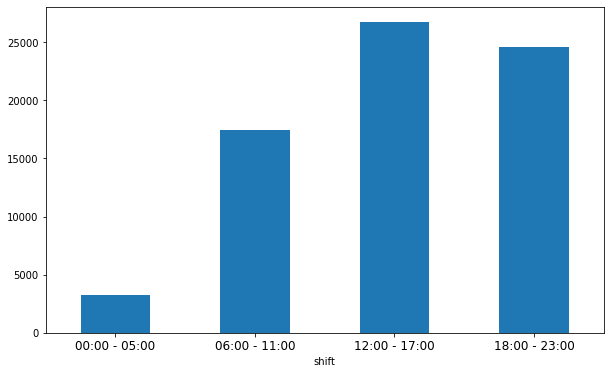

In [203]:
cashier_shift = pd.pivot_table(data = df,
                               values = 'receipt_id',
                               index = 'shift',
                               aggfunc = 'count')

cashier_shift.plot(kind = 'bar', legend = False)
plt.xticks(rotation = 0, fontsize = 12)
plt.show()

7. Berikan Rekomendasi
Kelompok Shift :
* 00.00 - 05.00
* 06.00 - 11.00
* 12.00 - 17.00
* 18.00 - 23.00

Jawab:

> Berdasarkan hasil visualisasibarplot, jika ingin melakukan efisiensi kasir, sebaiknya lakukan efisiensi pada shift jam 00.00 - 05.00 karena shift di jam tersebut memiliki jumlah transaksi yang paling sedikit sehingga tidak memerlukan banyak kasir/pekerja